In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
GPU count: 1


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.tensor([[90., 940., 42., 6400., 4.]])

print("BEFORE moving to GPU")
print("Shape :", x.shape)
print("Device:", x.device)

x = x.to(device)

print("\nAFTER moving to GPU")
print("Shape :", x.shape)
print("Device:", x.device)

BEFORE moving to GPU
Shape : torch.Size([1, 5])
Device: cpu

AFTER moving to GPU
Shape : torch.Size([1, 5])
Device: cuda:0


In [3]:
import torch.nn as nn

model = nn.Linear(5, 1)

print("BEFORE moving model")
print("Model weights device:", model.weight.device)

model = model.to(device)

print("\nAFTER moving model")
print("Model weights device:", model.weight.device)

BEFORE moving model
Model weights device: cpu

AFTER moving model
Model weights device: cuda:0


In [4]:
torch.manual_seed(42)

N = 10000

# 5 synthetic server features
temperature = torch.normal(75, 10, (N, 1))
power       = torch.normal(700, 150, (N, 1))
errors      = torch.poisson(torch.full((N, 1), 2.0))
fan_speed   = torch.normal(5000, 1000, (N, 1))
age         = torch.rand(N, 1) * 5

X_raw = torch.cat(
    [temperature, power, errors, fan_speed, age],
    dim=1
)

# Synthetic failure relationship
risk = (
    0.06 * (temperature - 75)
    + 0.002 * (power - 700)
    + 0.45 * (errors - 2)
    + 0.00025 * (fan_speed - 5000)
    + 0.35 * (age - 2.5)
)

probability = torch.sigmoid(risk)
y = torch.bernoulli(probability)

# Normalize features
feature_mean = X_raw.mean(dim=0)
feature_std = X_raw.std(dim=0)
X = (X_raw - feature_mean) / feature_std

print("X shape:", X.shape)
print("y shape:", y.shape)

print("X device:", X.device)
print("y device:", y.device)

print("Failure rate:", y.mean().item())

X shape: torch.Size([10000, 5])
y shape: torch.Size([10000, 1])
X device: cpu
y device: cpu
Failure rate: 0.4966999888420105


In [5]:
indices = torch.randperm(N)
train_size = int(0.8 * N)

train_idx = indices[:train_size]
test_idx  = indices[train_size:]

X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("BEFORE GPU")
print("X_train:", X_train.shape, X_train.device)
print("y_train:", y_train.shape, y_train.device)
print("X_test :", X_test.shape, X_test.device)
print("y_test :", y_test.shape, y_test.device)

# Move data to GPU
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)

print("\nAFTER GPU")
print("X_train:", X_train.shape, X_train.device)
print("y_train:", y_train.shape, y_train.device)
print("X_test :", X_test.shape, X_test.device)
print("y_test :", y_test.shape, y_test.device)

BEFORE GPU
X_train: torch.Size([8000, 5]) cpu
y_train: torch.Size([8000, 1]) cpu
X_test : torch.Size([2000, 5]) cpu
y_test : torch.Size([2000, 1]) cpu

AFTER GPU
X_train: torch.Size([8000, 5]) cuda:0
y_train: torch.Size([8000, 1]) cuda:0
X_test : torch.Size([2000, 5]) cuda:0
y_test : torch.Size([2000, 1]) cuda:0


In [6]:
# Build model directly and move it to GPU
model = nn.Linear(5, 1).to(device)

# Loss function
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

print(model)
print("Model device:", model.weight.device)
print("Weight shape:", model.weight.shape)
print("Bias shape:", model.bias.shape)

print("\nInitial weights:")
print(model.weight.data)

print("Initial bias:")
print(model.bias.data)

Linear(in_features=5, out_features=1, bias=True)
Model device: cuda:0
Weight shape: torch.Size([1, 5])
Bias shape: torch.Size([1])

Initial weights:
tensor([[-0.2898,  0.3176, -0.1436, -0.3009,  0.2256]], device='cuda:0')
Initial bias:
tensor([-0.2465], device='cuda:0')


In [7]:
loss_history = []

for epoch in range(101):

    optimizer.zero_grad()

    # Forward pass — GPU
    logits = model(X_train)

    # Calculate loss — GPU
    loss = loss_fn(logits, y_train)

    # Backpropagation — GPU
    loss.backward()

    # Update weights — GPU
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss {loss.item():.4f}")

print("\nTraining finished")
print("Logits device:", logits.device)
print("Loss device:", loss.device)
print("Model device:", model.weight.device)

Epoch   0 | Loss 0.7721
Epoch  20 | Loss 0.6586
Epoch  40 | Loss 0.6147
Epoch  60 | Loss 0.5968
Epoch  80 | Loss 0.5888
Epoch 100 | Loss 0.5850

Training finished
Logits device: cuda:0
Loss device: cuda:0
Model device: cuda:0


In [8]:
with torch.no_grad():

    test_logits = model(X_test)
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (test_probabilities >= 0.5).float()

    accuracy = (test_predictions == y_test).float().mean()

print("Test logits shape :", test_logits.shape)
print("Predictions shape :", test_predictions.shape)
print("Device            :", test_logits.device)
print("Test accuracy      :", round(accuracy.item(), 3))

Test logits shape : torch.Size([2000, 1])
Predictions shape : torch.Size([2000, 1])
Device            : cuda:0
Test accuracy      : 0.677


In [9]:
import time

def train_timed(device_name):

    Xtr = X[train_idx].to(device_name)
    ytr = y[train_idx].to(device_name)

    m = nn.Linear(5, 1).to(device_name)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    criterion = nn.BCEWithLogitsLoss()

    # Synchronize before timing GPU
    if device_name == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for epoch in range(101):
        opt.zero_grad()
        logits = m(Xtr)
        loss = criterion(logits, ytr)
        loss.backward()
        opt.step()

    # GPU operations are asynchronous, so wait for completion
    if device_name == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()

    return end - start


cpu_time = train_timed("cpu")
gpu_time = train_timed("cuda")

print(f"CPU training time: {cpu_time:.4f} seconds")
print(f"GPU training time: {gpu_time:.4f} seconds")
print(f"GPU / CPU ratio:   {gpu_time / cpu_time:.2f}x")

CPU training time: 0.0696 seconds
GPU training time: 0.0742 seconds
GPU / CPU ratio:   1.07x


In [10]:
import time

def train_timed(device_name):

    Xtr = X[train_idx].to(device_name)
    ytr = y[train_idx].to(device_name)

    m = nn.Linear(5, 1).to(device_name)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    criterion = nn.BCEWithLogitsLoss()

    # Synchronize before timing GPU
    if device_name == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for epoch in range(101):
        opt.zero_grad()
        logits = m(Xtr)
        loss = criterion(logits, ytr)
        loss.backward()
        opt.step()

    # GPU operations are asynchronous, so wait for completion
    if device_name == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()

    return end - start


cpu_time = train_timed("cpu")
gpu_time = train_timed("cuda")

print(f"CPU training time: {cpu_time:.4f} seconds")
print(f"GPU training time: {gpu_time:.4f} seconds")
print(f"GPU / CPU ratio:   {gpu_time / cpu_time:.2f}x")

CPU training time: 0.0542 seconds
GPU training time: 0.0745 seconds
GPU / CPU ratio:   1.38x


In [11]:
import time

# Much larger synthetic workload
N_BIG = 1_000_000
F_BIG = 100

torch.manual_seed(42)

X_big = torch.randn(N_BIG, F_BIG)
y_big = torch.randint(0, 2, (N_BIG, 1)).float()

print("Large X shape:", X_big.shape)
print("Large y shape:", y_big.shape)
print("Total feature values:", X_big.numel())

Large X shape: torch.Size([1000000, 100])
Large y shape: torch.Size([1000000, 1])
Total feature values: 100000000


In [12]:
def train_big_timed(device_name):

    Xd = X_big.to(device_name)
    yd = y_big.to(device_name)

    model_big = nn.Linear(F_BIG, 1).to(device_name)
    optimizer_big = torch.optim.SGD(model_big.parameters(), lr=0.01)
    loss_big = nn.BCEWithLogitsLoss()

    if device_name == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    # Only 20 epochs because this dataset is much larger
    for epoch in range(20):
        optimizer_big.zero_grad()

        logits = model_big(Xd)
        loss = loss_big(logits, yd)

        loss.backward()
        optimizer_big.step()

    if device_name == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()

    return end - start


cpu_big_time = train_big_timed("cpu")
gpu_big_time = train_big_timed("cuda")

print(f"Large workload CPU time: {cpu_big_time:.4f} seconds")
print(f"Large workload GPU time: {gpu_big_time:.4f} seconds")
print(f"CPU / GPU speedup:       {cpu_big_time / gpu_big_time:.2f}x")

Large workload CPU time: 1.8489 seconds
Large workload GPU time: 0.1005 seconds
CPU / GPU speedup:       18.40x


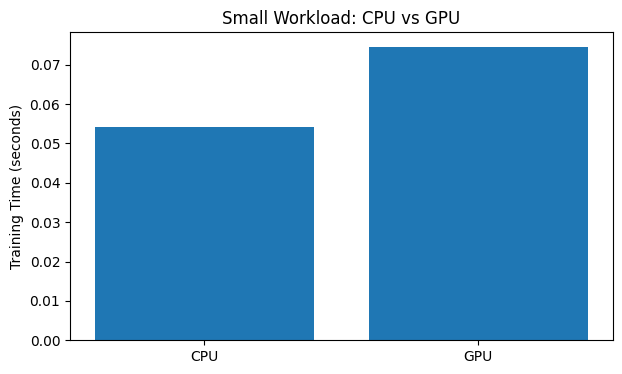

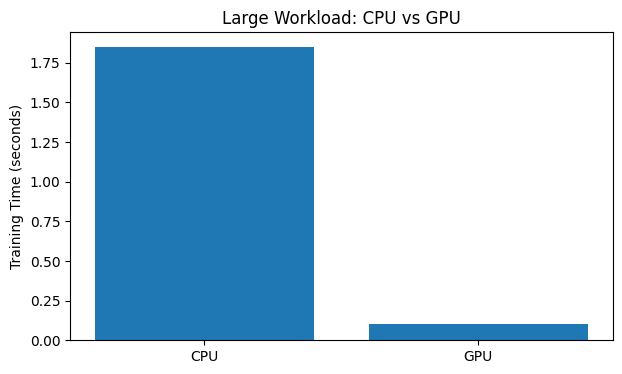

In [13]:
import matplotlib.pyplot as plt

devices = ["CPU", "GPU"]
small_times = [cpu_time, gpu_time]
large_times = [cpu_big_time, gpu_big_time]

plt.figure(figsize=(7, 4))
plt.bar(devices, small_times)
plt.ylabel("Training Time (seconds)")
plt.title("Small Workload: CPU vs GPU")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(devices, large_times)
plt.ylabel("Training Time (seconds)")
plt.title("Large Workload: CPU vs GPU")
plt.show()

In [14]:
print("=== COLAB 2 RESULTS ===")

print("\nSmall workload")
print(f"CPU: {cpu_time:.4f} sec")
print(f"GPU: {gpu_time:.4f} sec")
print(f"GPU/CPU ratio: {gpu_time/cpu_time:.2f}x")

print("\nLarge workload")
print(f"CPU: {cpu_big_time:.4f} sec")
print(f"GPU: {gpu_big_time:.4f} sec")
print(f"GPU speedup: {cpu_big_time/gpu_big_time:.2f}x")

print("\nKey takeaway:")
print("GPU acceleration depends on workload size and parallelism.")
print("Small workloads may be slower on GPU because overhead dominates.")
print("Large parallel workloads can benefit substantially from GPU execution.")

=== COLAB 2 RESULTS ===

Small workload
CPU: 0.0542 sec
GPU: 0.0745 sec
GPU/CPU ratio: 1.38x

Large workload
CPU: 1.8489 sec
GPU: 0.1005 sec
GPU speedup: 18.40x

Key takeaway:
GPU acceleration depends on workload size and parallelism.
Small workloads may be slower on GPU because overhead dominates.
Large parallel workloads can benefit substantially from GPU execution.
